In [73]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import normaltest
from scipy.stats import skew, kurtosis
from scipy.stats import spearmanr

In [3]:
df = pd.read_csv("final_dataset.csv")

In [5]:
df

,date,action,company,ticker,name,title,shares,avg_price,value_usd,entry_price,price_20d_after,price_1y_after,return_20d_w,return_1y_w
0,2006-01-04,Purchased,COLUMBIA BANKING SYSTEM INC,COLB,WHITNEY EVANS Q,Executive Vice President,18192.00,10.820000,1.968374e+05,14.488955,15.951273,17.373795,10.092643,19.910615
1,2006-01-09,Purchased,CALAMOS STRATEGIC TOTAL RETURN FUND,CSQ,CALAMOS JOHN P SR,president and chairman,45800.00,13.972380,6.399350e+05,2.466409,2.464649,2.974078,-0.071369,20.583302
2,2006-01-13,Purchased,FOSSIL INC,FOSL,KARTSOTIS KOSTA N,Pres. & CEO,70000.00,22.027543,1.541928e+06,22.139999,18.000000,23.020000,-18.699185,3.974711
3,2006-01-13,Purchased,NVR INC,NVR,SCHAR DWIGHT C,Chairman,127.87,814.960000,1.042089e+05,785.250000,726.000000,625.500000,-7.545368,-20.343840
4,2006-01-17,Purchased,STIFEL FINANCIAL CORP,SF,HIMELFARB RICHARD J,Director,80000.00,25.000000,2.000000e+06,6.662884,6.539882,7.984721,-1.846078,19.838819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17144,2026-03-30,Purchased,"CITIZENS, INC.",CIA,Stenberg Jon,President & CEO,50000.00,4.700000,2.350000e+05,4.820000,5.730000,NaN,18.879664,NaN
17145,2026-03-30,Purchased,Sibanye Stillwater Ltd,SBSW,Carter Charles Edward,Chief Regional Officer: Amer.,10000.00,11.400000,1.140000e+05,11.140000,11.930000,NaN,7.091561,NaN
17146,2026-03-30,Purchased,TAIWAN SEMICONDUCTOR MANUFACTURING CO LTD,TSM,Lin Shyue-Shyh,VP,3000.00,54.720000,1.641600e+05,315.760529,391.423340,NaN,23.962087,NaN
17147,2026-03-30,Purchased,"Zenas BioPharma, Inc.",ZBIO,MOULDER LEON O JR,Chief Executive Officer,20000.00,18.230000,3.646000e+05,18.225000,18.010000,NaN,-1.179699,NaN


In [7]:
df["title"].value_counts().head(10)

title
Chief Executive Officer    2311
President and CEO          1031
CEO & Chairman              911
President & CEO             714
Chairman and CEO            658
Chairman & CEO              535
CEO                         514
See Remarks                 489
Chief Financial Officer     481
President                   462
Name: count, dtype: int64

In [9]:
df.describe()

,shares,avg_price,value_usd,entry_price,price_20d_after,price_1y_after,return_20d_w,return_1y_w
count,1.714900e+04,1.714900e+04,1.714900e+04,1.714900e+04,1.714900e+04,1.582100e+04,17149.000000,15821.000000
mean,7.373168e+06,4.444187e+03,9.727382e+08,1.032000e+07,1.017354e+07,8.875052e+06,3.311416,17.047891
std,9.375275e+08,4.933471e+05,5.508572e+10,7.000718e+08,6.867728e+08,5.988316e+08,14.689006,61.402645
min,4.000000e+00,1.000000e-02,1.000000e+05,1.000000e+00,3.000000e-01,1.000000e-04,-41.046908,-86.056050
25%,8.000000e+03,8.440000e+00,1.499750e+05,6.842105e+00,6.916628e+00,7.288263e+00,-3.688053,-17.966903
50%,1.833700e+04,1.700000e+01,2.499807e+05,1.389952e+01,1.425432e+01,1.455323e+01,2.306210,7.705830
75%,5.000000e+04,3.398000e+01,5.568420e+05,3.097269e+01,3.188000e+01,3.205470e+01,9.348302,37.024608
max,1.227720e+11,6.451255e+07,5.169712e+12,5.823797e+10,5.515909e+10,5.016771e+10,58.933619,292.012986


In [11]:
stats = pd.DataFrame({
    "20 sesji": [
        df["return_20d_w"].count(),
        df["return_20d_w"].mean(),
        df["return_20d_w"].median(),
        df["return_20d_w"].std(),
        df["return_20d_w"].dropna().gt(0).mean() * 100
    ],
    "1 rok": [
        df["return_1y_w"].count(),
        df["return_1y_w"].mean(),
        df["return_1y_w"].median(),
        df["return_1y_w"].std(),
        df["return_1y_w"].dropna().gt(0).mean() * 100
    ]
}, index=[
    "Liczba obserwacji",
    "Średnia stopa zwrotu",
    "Mediana stopy zwrotu",
    "Odchylenie standardowe",
    "Hit rate"
])

stats.iloc[1:] = stats.iloc[1:].round(2)

print(stats)

                        20 sesji     1 rok
Liczba obserwacji       17149.00  15821.00
Średnia stopa zwrotu        3.31     17.05
Mediana stopy zwrotu        2.31      7.71
Odchylenie standardowe     14.69     61.40
Hit rate                   61.23     58.51


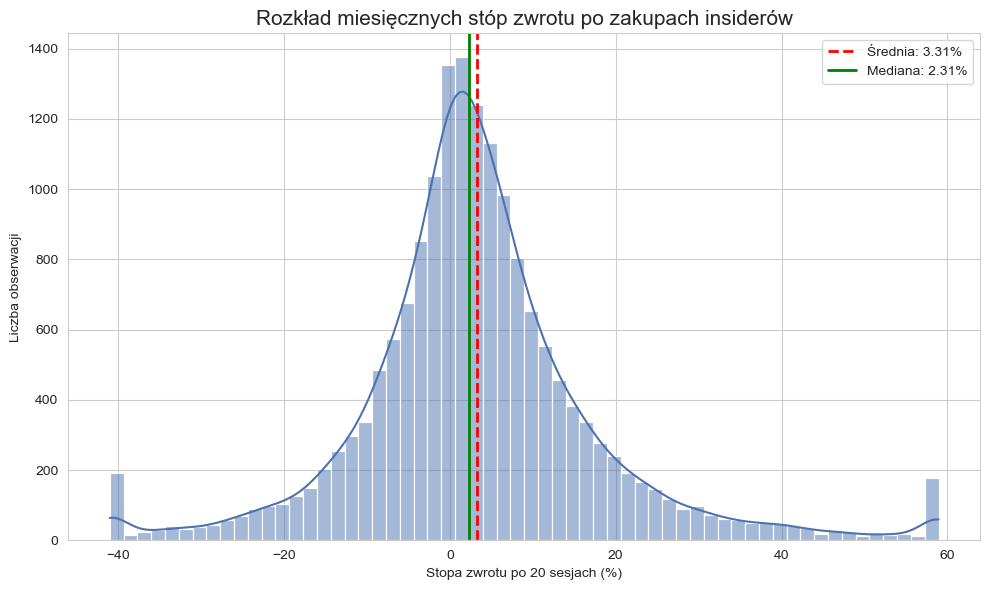

In [13]:
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(10,6))

sns.histplot(
    df["return_20d_w"],
    bins=60,
    kde=True,
    color="#4C72B0",
    edgecolor="white",
    ax=ax
)

mean = df["return_20d_w"].mean()
median = df["return_20d_w"].median()

ax.axvline(mean, color="red", linestyle="--", linewidth=2,
           label=f"Średnia: {mean:.2f}%")

ax.axvline(median, color="green", linestyle="-", linewidth=2,
           label=f"Mediana: {median:.2f}%")

ax.set_title("Rozkład miesięcznych stóp zwrotu po zakupach insiderów", fontsize=15)
ax.set_xlabel("Stopa zwrotu po 20 sesjach (%)")
ax.set_ylabel("Liczba obserwacji")

ax.legend()

plt.tight_layout()
plt.show()

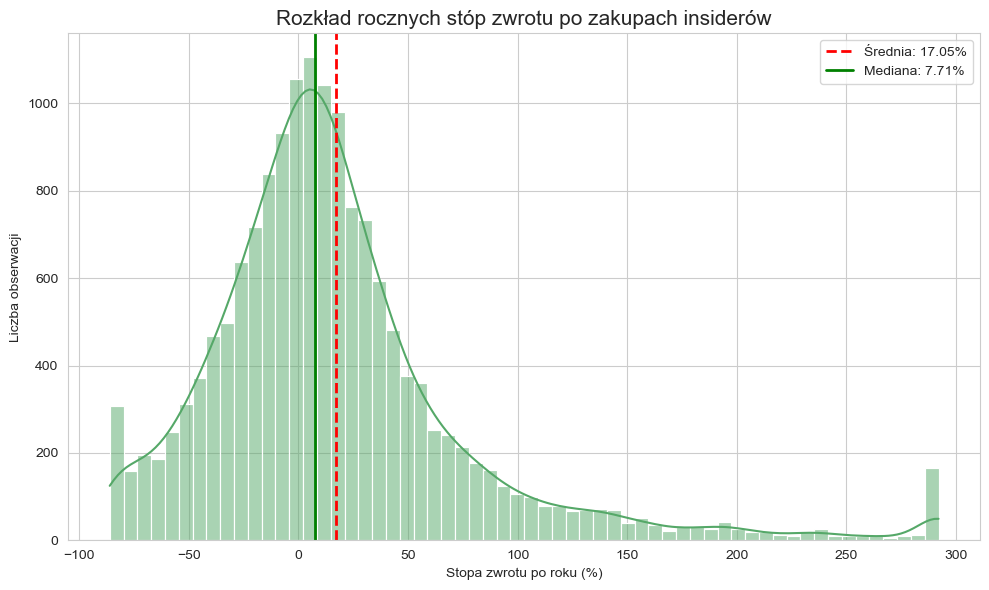

In [15]:
fig, ax = plt.subplots(figsize=(10,6))

sns.histplot(
    df["return_1y_w"],
    bins=60,
    kde=True,
    color="#55A868",
    edgecolor="white",
    ax=ax
)

mean = df["return_1y_w"].mean()
median = df["return_1y_w"].median()

ax.axvline(mean, color="red", linestyle="--", linewidth=2,
           label=f"Średnia: {mean:.2f}%")

ax.axvline(median, color="green", linestyle="-", linewidth=2,
           label=f"Mediana: {median:.2f}%")

ax.set_title("Rozkład rocznych stóp zwrotu po zakupach insiderów", fontsize=15)
ax.set_xlabel("Stopa zwrotu po roku (%)")
ax.set_ylabel("Liczba obserwacji")

ax.legend()

plt.tight_layout()
plt.show()

In [17]:
stat20, p20 = normaltest(df["return_20d_w"].dropna())
stat1y, p1y = normaltest(df["return_1y_w"].dropna())

print(f"miesiac: stat={stat20:.2f}, p={p20:.5g}")
print(f"1 rok : stat={stat1y:.2f}, p={p1y:.5g}")

miesiac: stat=1943.14, p=0
1 rok : stat=5713.83, p=0


In [19]:
for col in ["return_20d_w", "return_1y_w"]:
    x = df[col].dropna()

    print(col)
    print("N =", len(x))
    print("Skewness:", skew(x))
    print("Excess kurtosis:", kurtosis(x))

return_20d_w
N = 17149
Skewness: 0.5568567820936572
Excess kurtosis: 2.884912492607995
return_1y_w
N = 15821
Skewness: 1.748500605443615
Excess kurtosis: 4.9487854062491206


In [21]:
df["return_20d_w"].quantile([0.01,0.05,0.25,0.5,0.75,0.95,0.99])

0.01   -41.020987
0.05   -18.947943
0.25    -3.688053
0.50     2.306210
0.75     9.348302
0.95    28.538776
0.99    58.766694
Name: return_20d_w, dtype: float64

In [23]:
df["return_1y_w"].quantile([0.01,0.05,0.25,0.5,0.75,0.95,0.99])

0.01    -86.033894
0.05    -62.604132
0.25    -17.966903
0.50      7.705830
0.75     37.024608
0.95    133.990588
0.99    292.012986
Name: return_1y_w, dtype: float64

In [25]:
bins = [-float("inf"), -50, -25, 0, 25, 50, 100, float("inf")]

labels = [
    "< -50%",
    "-50% do -25%",
    "-25% do 0%",
    "0% do 25%",
    "25% do 50%",
    "50% do 100%",
    "> 100%"
]

dist_20d = (
    pd.cut(
        df["return_20d_w"],
        bins=bins,
        labels=labels
    )
    .value_counts()
    .sort_index()
)

dist_20d_pct = (dist_20d / dist_20d.sum() * 100).round(2)

print(pd.DataFrame({
    "Liczba obserwacji": dist_20d,
    "Udział": dist_20d_pct.astype(str) + "%"
}))

              Liczba obserwacji  Udział
return_20d_w                           
< -50%                        0    0.0%
-50% do -25%                514    3.0%
-25% do 0%                 6135  35.77%
0% do 25%                  9410  54.87%
25% do 50%                  844   4.92%
50% do 100%                 246   1.43%
> 100%                        0    0.0%


In [27]:
dist_1y = (
    pd.cut(
        df["return_1y_w"].dropna(),
        bins=bins,
        labels=labels
    )
    .value_counts()
    .sort_index()
)

dist_1y_pct = (dist_1y / dist_1y.sum() * 100).round(2)

print(pd.DataFrame({
    "Liczba obserwacji": dist_1y,
    "Udział": dist_1y_pct.astype(str) + "%"
}))

              Liczba obserwacji  Udział
return_1y_w                            
< -50%                     1322   8.36%
-50% do -25%               1847  11.67%
-25% do 0%                 3395  21.46%
0% do 25%                  3998  25.27%
25% do 50%                 2316  14.64%
50% do 100%                1715  10.84%
> 100%                     1228   7.76%


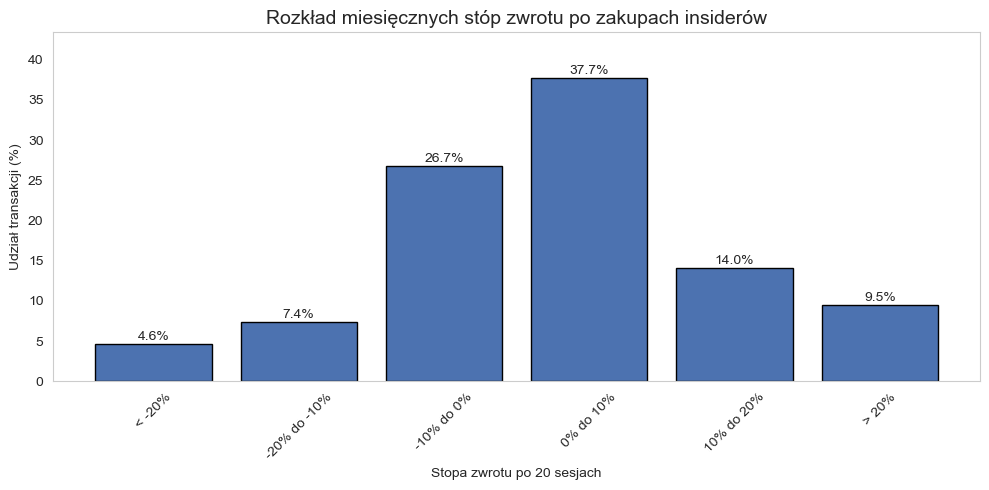

In [29]:
bins_20d = [
    -float("inf"),
    -20,
    -10,
    0,
    10,
    20,
    float("inf")
]

labels_20d = [
    "< -20%",
    "-20% do -10%",
    "-10% do 0%",
    "0% do 10%",
    "10% do 20%",
    "> 20%"
]

dist_20d = (
    pd.cut(
        df["return_20d_w"].dropna(),
        bins=bins_20d,
        labels=labels_20d
    )
    .value_counts()
    .sort_index()
)

dist_20d_pct = dist_20d / dist_20d.sum() * 100


plt.figure(figsize=(10,5))

bars = plt.bar(
    dist_20d_pct.index,
    dist_20d_pct.values,
    color="#4C72B0",
    edgecolor="black"
)

plt.title(
    "Rozkład miesięcznych stóp zwrotu po zakupach insiderów",
    fontsize=14
)

plt.xlabel("Stopa zwrotu po 20 sesjach")
plt.ylabel("Udział transakcji (%)")

plt.xticks(rotation=45)

# etykiety procentowe
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center",
        fontsize=10
    )

plt.ylim(0, max(dist_20d_pct.values)*1.15)

plt.grid(False)
plt.tight_layout()
plt.show()

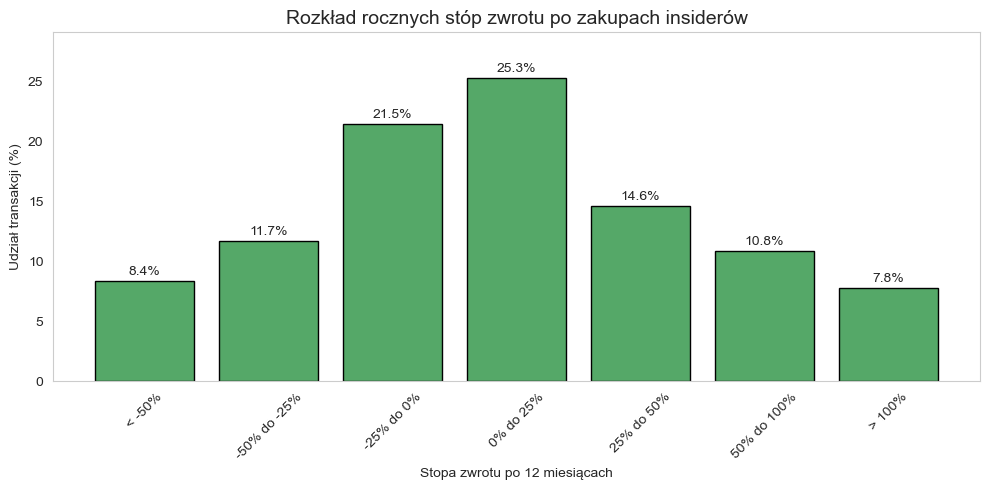

In [31]:
bins_1y = [
    -float("inf"),
    -50,
    -25,
    0,
    25,
    50,
    100,
    float("inf")
]

labels_1y = [
    "< -50%",
    "-50% do -25%",
    "-25% do 0%",
    "0% do 25%",
    "25% do 50%",
    "50% do 100%",
    "> 100%"
]


dist_1y = (
    pd.cut(
        df["return_1y_w"].dropna(),
        bins=bins_1y,
        labels=labels_1y
    )
    .value_counts()
    .sort_index()
)

dist_1y_pct = dist_1y / dist_1y.sum() * 100


plt.figure(figsize=(10,5))

bars = plt.bar(
    dist_1y_pct.index,
    dist_1y_pct.values,
    color="#55A868",
    edgecolor="black"
)

plt.title(
    "Rozkład rocznych stóp zwrotu po zakupach insiderów",
    fontsize=14
)

plt.xlabel("Stopa zwrotu po 12 miesiącach")
plt.ylabel("Udział transakcji (%)")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center",
        fontsize=10
    )

plt.ylim(0, max(dist_1y_pct.values)*1.15)

plt.grid(False)
plt.tight_layout()
plt.show()

In [33]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.to_period("M")

In [35]:
df

,date,action,company,ticker,name,title,shares,avg_price,value_usd,entry_price,price_20d_after,price_1y_after,return_20d_w,return_1y_w,year,month
0,2006-01-04,Purchased,COLUMBIA BANKING SYSTEM INC,COLB,WHITNEY EVANS Q,Executive Vice President,18192.00,10.820000,1.968374e+05,14.488955,15.951273,17.373795,10.092643,19.910615,2006,2006-01
1,2006-01-09,Purchased,CALAMOS STRATEGIC TOTAL RETURN FUND,CSQ,CALAMOS JOHN P SR,president and chairman,45800.00,13.972380,6.399350e+05,2.466409,2.464649,2.974078,-0.071369,20.583302,2006,2006-01
2,2006-01-13,Purchased,FOSSIL INC,FOSL,KARTSOTIS KOSTA N,Pres. & CEO,70000.00,22.027543,1.541928e+06,22.139999,18.000000,23.020000,-18.699185,3.974711,2006,2006-01
3,2006-01-13,Purchased,NVR INC,NVR,SCHAR DWIGHT C,Chairman,127.87,814.960000,1.042089e+05,785.250000,726.000000,625.500000,-7.545368,-20.343840,2006,2006-01
4,2006-01-17,Purchased,STIFEL FINANCIAL CORP,SF,HIMELFARB RICHARD J,Director,80000.00,25.000000,2.000000e+06,6.662884,6.539882,7.984721,-1.846078,19.838819,2006,2006-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17144,2026-03-30,Purchased,"CITIZENS, INC.",CIA,Stenberg Jon,President & CEO,50000.00,4.700000,2.350000e+05,4.820000,5.730000,NaN,18.879664,NaN,2026,2026-03
17145,2026-03-30,Purchased,Sibanye Stillwater Ltd,SBSW,Carter Charles Edward,Chief Regional Officer: Amer.,10000.00,11.400000,1.140000e+05,11.140000,11.930000,NaN,7.091561,NaN,2026,2026-03
17146,2026-03-30,Purchased,TAIWAN SEMICONDUCTOR MANUFACTURING CO LTD,TSM,Lin Shyue-Shyh,VP,3000.00,54.720000,1.641600e+05,315.760529,391.423340,NaN,23.962087,NaN,2026,2026-03
17147,2026-03-30,Purchased,"Zenas BioPharma, Inc.",ZBIO,MOULDER LEON O JR,Chief Executive Officer,20000.00,18.230000,3.646000e+05,18.225000,18.010000,NaN,-1.179699,NaN,2026,2026-03


In [37]:
monthly_stats = df.groupby("month").agg(
    mean_return=("return_20d_w", "mean"),
    median_return=("return_20d_w", "median"),
    hit_rate=("return_20d_w", lambda x: x.dropna().gt(0).mean())
).reset_index()

In [39]:
monthly_stats["year"] = monthly_stats["month"].dt.year

In [41]:
monthly_stats

,month,mean_return,median_return,hit_rate,year
0,2006-01,1.794449,0.084410,0.650000,2006
1,2006-02,3.692844,2.049824,0.666667,2006
2,2006-03,2.320494,1.006430,0.608696,2006
3,2006-04,6.112277,0.536751,0.571429,2006
4,2006-05,-3.211105,-1.581306,0.403509,2006
...,...,...,...,...,...
238,2025-11,7.986093,5.397069,0.785408,2025
239,2025-12,5.009878,3.503179,0.722222,2025
240,2026-01,-3.033963,-5.417479,0.400000,2026
241,2026-02,-1.701260,-3.684923,0.366071,2026


In [43]:
yearly_stats = df.groupby("year").agg(
    mean_return=("return_20d_w", "mean"),
    median_return=("return_20d_w", "median"),
    hit_rate=("return_20d_w", lambda x: x.dropna().gt(0).mean()),
    n_obs=("return_20d_w", "count")
).reset_index()

In [45]:
yearly_stats

,year,mean_return,median_return,hit_rate,n_obs
0,2006,3.144900,2.267226,0.644706,425
1,2007,2.899506,3.008990,0.652470,587
2,2008,1.371800,0.242715,0.510083,843
3,2009,11.002573,6.131396,0.729167,384
4,2010,3.750564,2.972180,0.644351,478
5,2011,3.804177,2.334638,0.608631,672
6,2012,3.237201,2.443999,0.662609,575
7,2013,3.967250,2.069421,0.641441,555
8,2014,1.852538,1.704881,0.614815,675
9,2015,-0.252719,-0.199014,0.485915,994


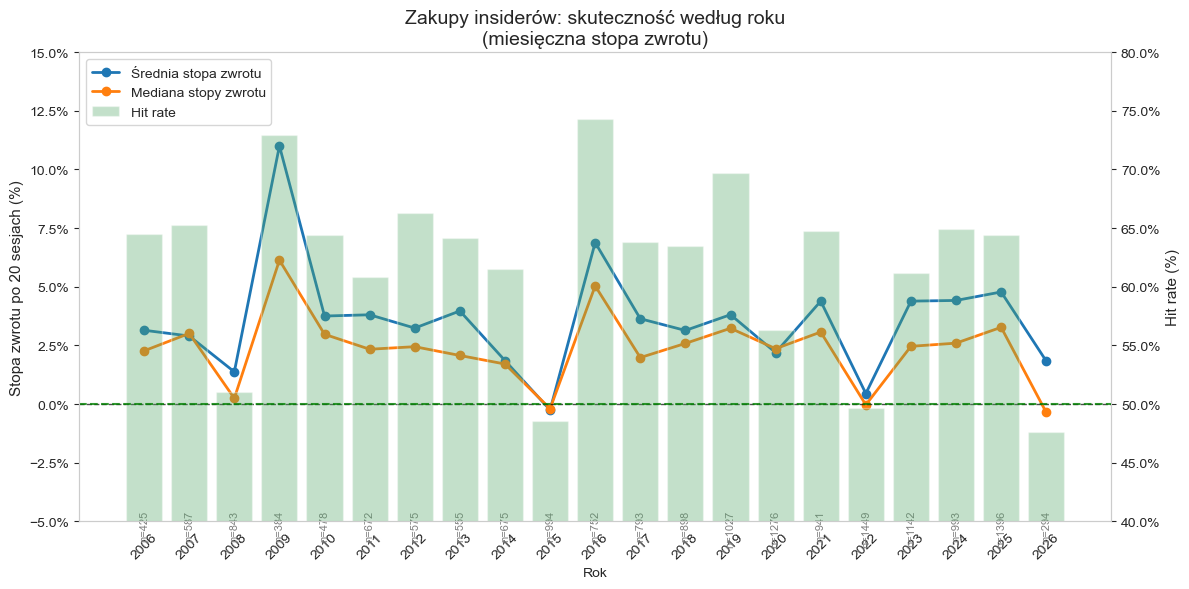

In [47]:
plt.rcParams["axes.grid"] = False


fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(
    yearly_stats["year"],
    yearly_stats["mean_return"],
    color="#1f77b4",
    marker="o",
    linewidth=2,
    label="Średnia stopa zwrotu"
)

ax1.plot(
    yearly_stats["year"],
    yearly_stats["median_return"],
    color="#ff7f0e",
    marker="o",
    linewidth=2,
    label="Mediana stopy zwrotu"
)

ax1.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)

ax1.set_ylabel(
    "Stopa zwrotu po 20 sesjach (%)",
    fontsize=11
)

ax1.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)

ax1.set_ylim(-5, 15)


ax2 = ax1.twinx()

ax2.bar(
    yearly_stats["year"],
    yearly_stats["hit_rate"] * 100,
    color="#55A868",
    alpha=0.35,
    width=0.8,
    label="Hit rate"
)

ax2.axhline(
    50,
    color="green",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

ax2.set_ylabel(
    "Hit rate (%)",
    fontsize=11
)

ax2.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)

ax2.set_ylim(40, 80)

ax1.set_title(
    "Zakupy insiderów: skuteczność według roku\n"
    "(miesięczna stopa zwrotu)",
    fontsize=14
)

ax1.set_xlabel(
    "Rok"
)

ax1.set_xticks(
    yearly_stats["year"]
)

ax1.tick_params(
    axis="x",
    rotation=45
)


for x, n in zip(
    yearly_stats["year"],
    yearly_stats["n_obs"]
):
    ax1.text(
        x,
        -4.5,
        f"n={n}",
        ha="center",
        va="top",
        fontsize=8,
        color="gray",
        rotation=90
    )


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)


ax1.grid(False)
ax2.grid(False)


plt.tight_layout()
plt.show()

In [49]:
yearly_stats_1y = df.groupby("year").agg(
    mean_return=("return_1y_w", "mean"),
    median_return=("return_1y_w", "median"),
    hit_rate=("return_1y_w", lambda x: (x.dropna() > 0).mean()),
    n_obs=("return_1y_w", "count")
).reset_index()

In [51]:
yearly_stats_1y = yearly_stats_1y[
    (yearly_stats_1y["year"] >= 2006) &
    (yearly_stats_1y["year"] <= 2025)
]

In [53]:
yearly_stats_1y

,year,mean_return,median_return,hit_rate,n_obs
0,2006,23.008094,16.097217,0.720000,425
1,2007,-18.397671,-17.423858,0.284497,587
2,2008,7.712018,-10.342074,0.376038,843
3,2009,71.530349,47.785696,0.875000,384
4,2010,16.450130,9.446141,0.633891,478
5,2011,12.287409,11.182539,0.635417,672
6,2012,51.923568,44.998234,0.869565,575
7,2013,19.784440,16.549873,0.792419,554
8,2014,14.123512,7.899616,0.635556,675
9,2015,5.776683,4.684840,0.592555,994


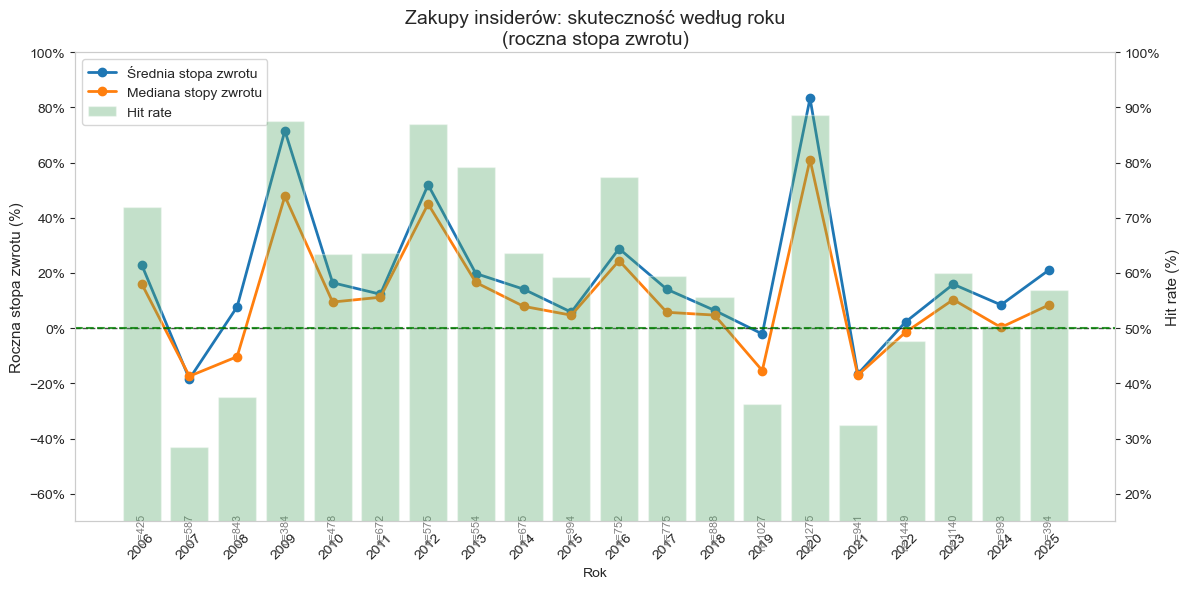

In [55]:
plt.rcParams["axes.grid"] = False

plot_data = yearly_stats_1y[
    (yearly_stats_1y["year"] >= 2006) &
    (yearly_stats_1y["year"] <= 2025)
]


fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(
    plot_data["year"],
    plot_data["mean_return"],
    color="#1f77b4",
    marker="o",
    linewidth=2,
    label="Średnia stopa zwrotu"
)

ax1.plot(
    plot_data["year"],
    plot_data["median_return"],
    color="#ff7f0e",
    marker="o",
    linewidth=2,
    label="Mediana stopy zwrotu"
)


ax1.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)


ax1.set_ylabel(
    "Roczna stopa zwrotu (%)",
    fontsize=11
)

ax1.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


ax1.set_ylim(-70, 100)

ax2 = ax1.twinx()


ax2.bar(
    plot_data["year"],
    plot_data["hit_rate"] * 100,
    color="#55A868",
    alpha=0.35,
    width=0.8,
    label="Hit rate"
)


ax2.axhline(
    50,
    color="green",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)


ax2.set_ylabel(
    "Hit rate (%)",
    fontsize=11
)

ax2.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


ax2.set_ylim(15, 100)

ax1.set_title(
    "Zakupy insiderów: skuteczność według roku\n"
    "(roczna stopa zwrotu)",
    fontsize=14
)


ax1.set_xlabel(
    "Rok"
)


ax1.set_xticks(
    plot_data["year"]
)


ax1.tick_params(
    axis="x",
    rotation=45
)


for x, n in zip(
    plot_data["year"],
    plot_data["n_obs"]
):
    ax1.text(
        x,
        -67,
        f"n={n}",
        ha="center",
        va="top",
        fontsize=8,
        color="gray",
        rotation=90
    )


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()


ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)


ax1.grid(False)
ax2.grid(False)


plt.tight_layout()
plt.show()

In [57]:
yearly_insider = df.groupby("year").agg(
    insider_volume_usd=("value_usd", "sum"),
    n_transactions=("value_usd", "count"),
    median_transaction=("value_usd", "median")
).reset_index()

In [59]:
yearly_insider

,year,insider_volume_usd,n_transactions,median_transaction
0,2006,1.426666e+11,425,258013.370
1,2007,6.318446e+08,587,244200.000
2,2008,4.180093e+12,843,256870.000
3,2009,4.289718e+08,384,214975.000
4,2010,9.488566e+11,478,270810.705
5,2011,3.250260e+10,672,221332.500
6,2012,8.819278e+11,575,199994.840
7,2013,5.256671e+12,555,226765.000
8,2014,3.968670e+08,675,240000.000
9,2015,9.210856e+08,994,202470.000


In [61]:
yearly_insider["log_insider_volume"] = np.log10(
    yearly_insider["insider_volume_usd"]
)

In [63]:
analysis_year = yearly_stats_1y.merge(
    yearly_insider,
    on="year",
    how="left"
)

In [65]:
analysis_year

,year,mean_return,median_return,hit_rate,n_obs,insider_volume_usd,n_transactions,median_transaction,log_insider_volume
0,2006,23.008094,16.097217,0.720000,425,1.426666e+11,425,258013.370,11.154322
1,2007,-18.397671,-17.423858,0.284497,587,6.318446e+08,587,244200.000,8.800610
2,2008,7.712018,-10.342074,0.376038,843,4.180093e+12,843,256870.000,12.621186
3,2009,71.530349,47.785696,0.875000,384,4.289718e+08,384,214975.000,8.632429
4,2010,16.450130,9.446141,0.633891,478,9.488566e+11,478,270810.705,11.977201
5,2011,12.287409,11.182539,0.635417,672,3.250260e+10,672,221332.500,10.511918
6,2012,51.923568,44.998234,0.869565,575,8.819278e+11,575,199994.840,11.945433
7,2013,19.784440,16.549873,0.792419,554,5.256671e+12,555,226765.000,12.720711
8,2014,14.123512,7.899616,0.635556,675,3.968670e+08,675,240000.000,8.598645
9,2015,5.776683,4.684840,0.592555,994,9.210856e+08,994,202470.000,8.964300


In [69]:
from scipy.stats import pearsonr, spearmanr

cols = [
    "log_insider_volume",
    "mean_return",
    "median_return",
    "hit_rate"
]

results = []

for x in ["mean_return", "median_return", "hit_rate"]:
    
    pearson_r, pearson_p = pearsonr(
        analysis_year["log_insider_volume"],
        analysis_year[x]
    )
    
    spearman_r, spearman_p = spearmanr(
        analysis_year["log_insider_volume"],
        analysis_year[x]
    )
    
    results.append({
        "zmienna": x,
        "Pearson r": pearson_r,
        "Pearson p": pearson_p,
        "Spearman rho": spearman_r,
        "Spearman p": spearman_p
    })

correlation_results = pd.DataFrame(results)

correlation_results

,zmienna,Pearson r,Pearson p,Spearman rho,Spearman p
0,mean_return,-0.232792,0.323300,-0.212030,0.369486
1,median_return,-0.260675,0.266981,-0.213534,0.366021
2,hit_rate,-0.200015,0.397838,-0.243609,0.300668


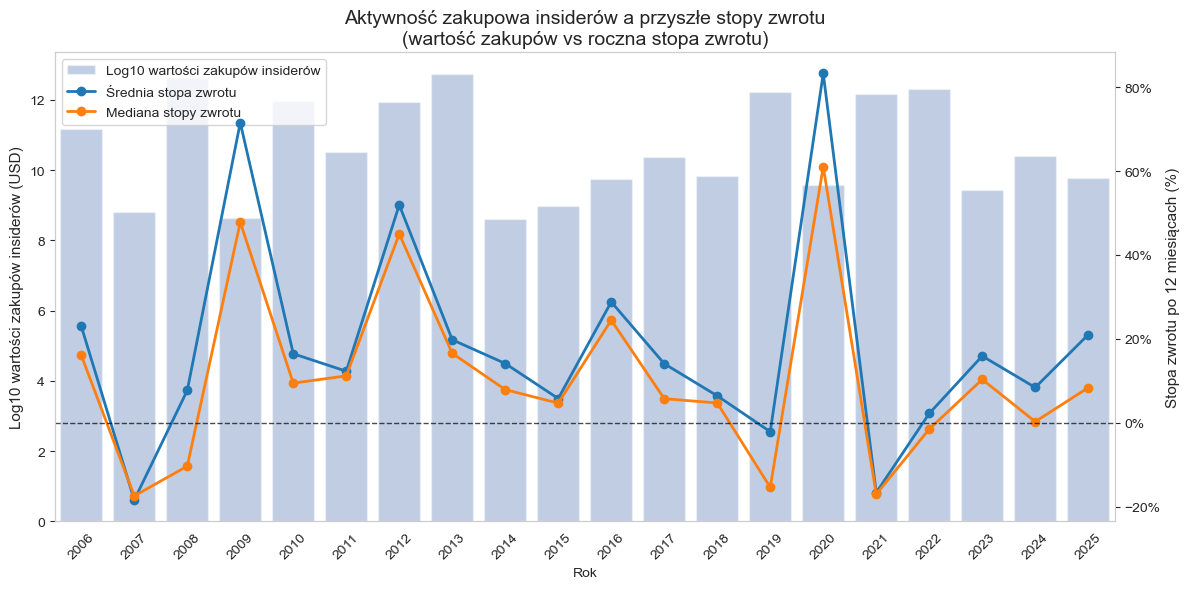

In [71]:
plt.rcParams["axes.grid"] = False


fig, ax1 = plt.subplots(figsize=(12,6))

bars = ax1.bar(
    analysis_year["year"],
    analysis_year["log_insider_volume"],
    color="#4C72B0",
    alpha=0.35,
    width=0.8,
    label="Log10 wartości zakupów insiderów"
)

ax1.set_ylabel(
    "Log10 wartości zakupów insiderów (USD)",
    fontsize=11
)

ax2 = ax1.twinx()


ax2.plot(
    analysis_year["year"],
    analysis_year["mean_return"],
    color="#1f77b4",
    marker="o",
    linewidth=2,
    label="Średnia stopa zwrotu"
)


ax2.plot(
    analysis_year["year"],
    analysis_year["median_return"],
    color="#ff7f0e",
    marker="o",
    linewidth=2,
    label="Mediana stopy zwrotu"
)

ax2.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)


ax2.set_ylabel(
    "Stopa zwrotu po 12 miesiącach (%)",
    fontsize=11
)

ax2.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


ax1.set_xlim(
    2005.5,
    2025.5
)


ax1.set_xticks(
    analysis_year["year"]
)

ax1.tick_params(
    axis="x",
    rotation=45
)

ax1.set_xlabel(
    "Rok"
)


ax1.set_title(
    "Aktywność zakupowa insiderów a przyszłe stopy zwrotu\n"
    "(wartość zakupów vs roczna stopa zwrotu)",
    fontsize=14
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

ax1.grid(False)
ax2.grid(False)


plt.tight_layout()
plt.show()

In [75]:
corr_data = df[
    [
        "value_usd",
        "return_1y_w"
    ]
].dropna()


spearman_corr, p_value = spearmanr(
    corr_data["value_usd"],
    corr_data["return_1y_w"]
)


print(f"Spearman correlation: {spearman_corr:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"N observations: {len(corr_data)}")

Spearman correlation: -0.0268
p-value: 0.000750
N observations: 15821


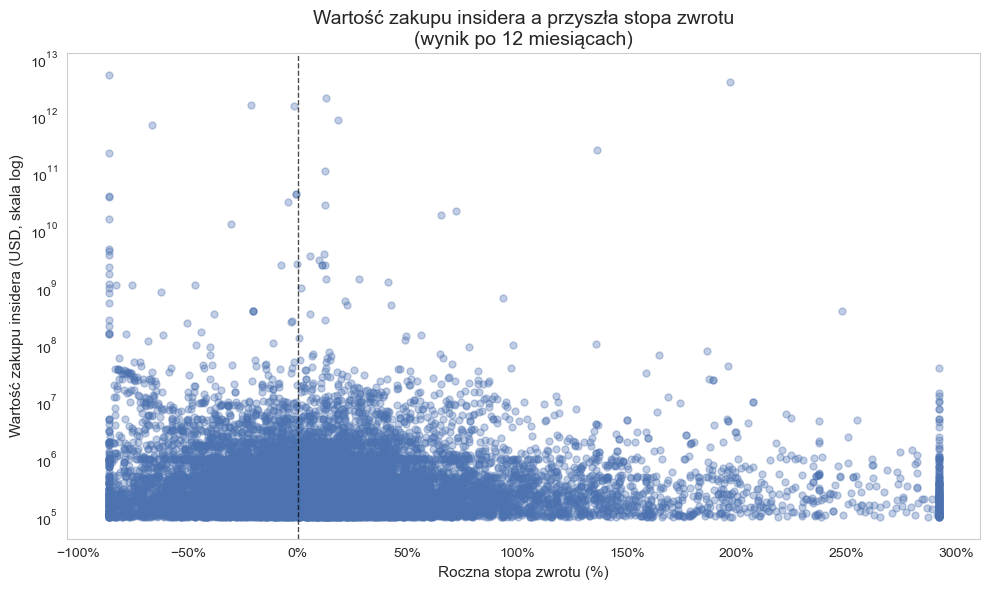

In [77]:
plot_data = df[
    [
        "value_usd",
        "return_1y_w",
        "year"
    ]
].dropna()


fig, ax = plt.subplots(figsize=(10,6))


scatter = ax.scatter(
    plot_data["return_1y_w"],
    plot_data["value_usd"],
    alpha=0.35,
    s=25,
    color="#4C72B0"
)


ax.set_yscale("log")


ax.xaxis.set_major_formatter(
    mtick.PercentFormatter()
)


ax.set_xlabel(
    "Roczna stopa zwrotu (%)",
    fontsize=11
)


ax.set_ylabel(
    "Wartość zakupu insidera (USD, skala log)",
    fontsize=11
)


ax.set_title(
    "Wartość zakupu insidera a przyszła stopa zwrotu\n"
    "(wynik po 12 miesiącach)",
    fontsize=14
)


ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)


ax.grid(False)


plt.tight_layout()
plt.show()

In [79]:
df_test = df[
    [
        "value_usd",
        "return_1y_w"
    ]
].dropna()


df_test["purchase_size_group"] = pd.qcut(
    df_test["value_usd"],
    5,
    labels=[
        "Q1 najmniejsze",
        "Q2",
        "Q3",
        "Q4",
        "Q5 największe"
    ]
)


quartile_results = df_test.groupby(
    "purchase_size_group"
).agg(
    n=("return_1y_w","count"),
    mean_return=("return_1y_w","mean"),
    median_return=("return_1y_w","median"),
    hit_rate=("return_1y_w", lambda x: (x>0).mean())
)

quartile_results

C:\Users\lukas\AppData\Local\Temp\ipykernel_28364\4056439303.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quartile_results = df_test.groupby(


,n,mean_return,median_return,hit_rate
purchase_size_group,,,,
Q1 najmniejsze,3165,17.646909,7.103618,0.598104
Q2,3164,18.818880,9.368661,0.596081
Q3,3164,17.910199,8.990224,0.590076
Q4,3166,18.632229,7.355941,0.583070
Q5 największe,3162,12.227001,6.213827,0.558191


In [81]:
df_test_20d = df[
    [
        "value_usd",
        "return_20d_w"
    ]
].dropna()


df_test_20d["purchase_size_group"] = pd.qcut(
    df_test_20d["value_usd"],
    5,
    labels=[
        "Q1 najmniejsze",
        "Q2",
        "Q3",
        "Q4",
        "Q5 największe"
    ]
)

In [83]:
quantile_results_20d = df_test_20d.groupby(
    "purchase_size_group",
    observed=True
).agg(
    n=("return_20d_w", "count"),
    mean_return=("return_20d_w", "mean"),
    median_return=("return_20d_w", "median"),
    hit_rate=("return_20d_w", lambda x: (x > 0).mean())
)


quantile_results_20d

,n,mean_return,median_return,hit_rate
purchase_size_group,,,,
Q1 najmniejsze,3430,3.267849,1.960038,0.600292
Q2,3431,3.211332,2.247196,0.601574
Q3,3433,3.129062,2.356818,0.615497
Q4,3428,3.449183,2.417568,0.617270
Q5 największe,3427,3.500086,2.583578,0.626787


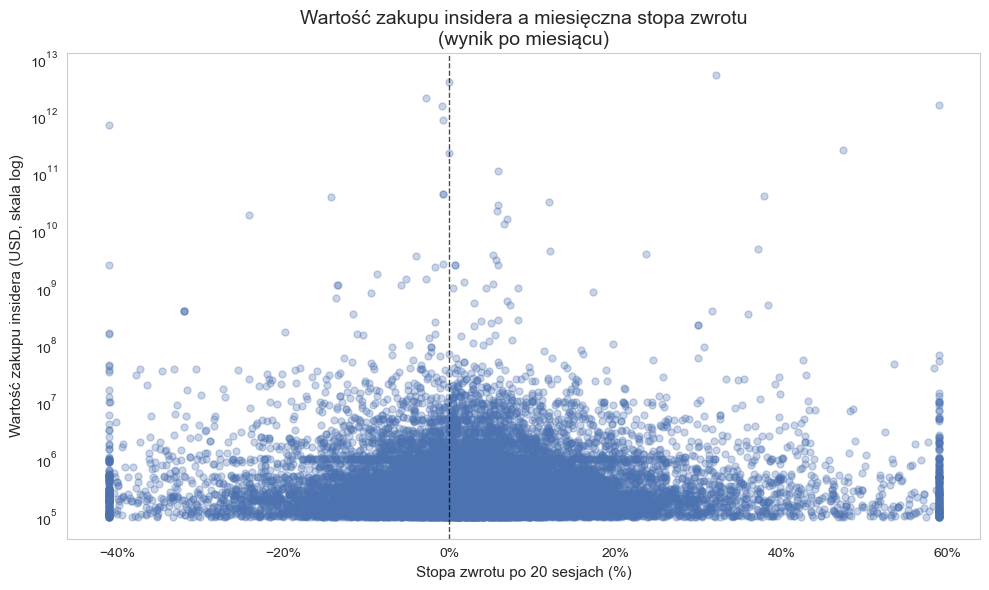

In [85]:
plot_data_20d = df[
    [
        "value_usd",
        "return_20d_w"
    ]
].dropna()


fig, ax = plt.subplots(figsize=(10,6))


ax.scatter(
    plot_data_20d["return_20d_w"],
    plot_data_20d["value_usd"],
    alpha=0.30,
    s=25,
    color="#4C72B0"
)


ax.set_yscale("log")


ax.xaxis.set_major_formatter(
    mtick.PercentFormatter()
)


ax.set_xlabel(
    "Stopa zwrotu po 20 sesjach (%)",
    fontsize=11
)


ax.set_ylabel(
    "Wartość zakupu insidera (USD, skala log)",
    fontsize=11
)


ax.set_title(
    "Wartość zakupu insidera a miesięczna stopa zwrotu\n"
    "(wynik po miesiącu)",
    fontsize=14
)


ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)


ax.grid(False)


plt.tight_layout()
plt.show()

In [87]:
corr_20d, p_20d = spearmanr(
    df_test_20d["value_usd"],
    df_test_20d["return_20d_w"]
)


print(f"Spearman correlation: {corr_20d:.4f}")
print(f"p-value: {p_20d:.6f}")
print(f"N observations: {len(df_test_20d)}")

Spearman correlation: 0.0135
p-value: 0.077387
N observations: 17149


In [89]:
sp500 = yf.download("^GSPC", start="2005-01-01", end="2026-03-31", progress=False, auto_adjust=True)

sp500 = sp500.reset_index()

sp500['year'] = sp500['Date'].dt.year

annual_close = sp500.groupby('year')['Close'].last().sort_index()
sp500_annual_return = annual_close.pct_change().dropna().reset_index()
sp500_annual_return.columns = ['year', 'sp500_annual_return']

sp500_annual_return

,year,sp500_annual_return
0,2006,0.136194
1,2007,0.035296
2,2008,-0.384858
3,2009,0.234542
4,2010,0.127827
5,2011,-0.000032
6,2012,0.134057
7,2013,0.296012
8,2014,0.113906
9,2015,-0.007266


In [91]:
sp500

Price,Date,Close,High,Low,Open,Volume,year
Ticker,,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,
0,2005-01-03,1202.079956,1217.800049,1200.319946,1211.920044,1510800000,2005
1,2005-01-04,1188.050049,1205.839966,1185.390015,1202.079956,1721000000,2005
2,2005-01-05,1183.739990,1192.729980,1183.719971,1188.050049,1738900000,2005
3,2005-01-06,1187.890015,1191.630005,1183.270020,1183.739990,1569100000,2005
4,2005-01-07,1186.189941,1192.199951,1182.160034,1187.890015,1477900000,2005
...,...,...,...,...,...,...,...
5338,2026-03-24,6556.370117,6595.750000,6525.109863,6552.089844,5278580000,2026
5339,2026-03-25,6591.899902,6633.939941,6568.410156,6598.350098,4936720000,2026
5340,2026-03-26,6477.160156,6573.220215,6473.790039,6555.859863,4845560000,2026


In [93]:
sp500 = sp500.copy()

sp500.columns = sp500.columns.get_level_values(0)

sp500 = sp500[
    sp500["Date"] != "Ticker"
].copy()

sp500["Date"] = pd.to_datetime(
    sp500["Date"]
)

In [95]:
print(sp500.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'year'], dtype='object', name='Price')


In [97]:
sp500["sp500_return_20d"] = (
    (
        sp500["Close"].shift(-20)
        /
        sp500["Close"]
        - 1
    )
    * 100
)

In [99]:
sp500

Price,Date,Close,High,Low,Open,Volume,year,sp500_return_20d
0,2005-01-03,1202.079956,1217.800049,1200.319946,1211.920044,1510800000,2005,-1.054000
1,2005-01-04,1188.050049,1205.839966,1185.390015,1202.079956,1721000000,2005,0.432633
2,2005-01-05,1183.739990,1192.729980,1183.719971,1188.050049,1738900000,2005,0.519542
3,2005-01-06,1187.890015,1191.630005,1183.270020,1183.739990,1569100000,2005,1.274530
4,2005-01-07,1186.189941,1192.199951,1182.160034,1187.890015,1477900000,2005,1.309236
...,...,...,...,...,...,...,...,...
5338,2026-03-24,6556.370117,6595.750000,6525.109863,6552.089844,5278580000,2026,NaN
5339,2026-03-25,6591.899902,6633.939941,6568.410156,6598.350098,4936720000,2026,NaN
5340,2026-03-26,6477.160156,6573.220215,6473.790039,6555.859863,4845560000,2026,NaN
5341,2026-03-27,6368.850098,6453.890137,6356.080078,6453.890137,5303490000,2026,NaN


In [101]:
df_market = df.merge(
    sp500[
        [
            "Date",
            "Close",
            "sp500_return_20d"
        ]
    ],
    left_on="date",
    right_on="Date",
    how="left"
)

In [103]:
df_market

,date,action,company,ticker,name,title,shares,avg_price,value_usd,entry_price,price_20d_after,price_1y_after,return_20d_w,return_1y_w,year,month,Date,Close,sp500_return_20d
0,2006-01-04,Purchased,COLUMBIA BANKING SYSTEM INC,COLB,WHITNEY EVANS Q,Executive Vice President,18192.00,10.820000,1.968374e+05,14.488955,15.951273,17.373795,10.092643,19.910615,2006,2006-01,2006-01-04,1273.459961,-0.205738
1,2006-01-09,Purchased,CALAMOS STRATEGIC TOTAL RETURN FUND,CSQ,CALAMOS JOHN P SR,president and chairman,45800.00,13.972380,6.399350e+05,2.466409,2.464649,2.974078,-0.071369,20.583302,2006,2006-01,2006-01-09,1290.150024,-2.741541
2,2006-01-13,Purchased,FOSSIL INC,FOSL,KARTSOTIS KOSTA N,Pres. & CEO,70000.00,22.027543,1.541928e+06,22.139999,18.000000,23.020000,-18.699185,3.974711,2006,2006-01,2006-01-13,1287.609985,-1.922166
3,2006-01-13,Purchased,NVR INC,NVR,SCHAR DWIGHT C,Chairman,127.87,814.960000,1.042089e+05,785.250000,726.000000,625.500000,-7.545368,-20.343840,2006,2006-01,2006-01-13,1287.609985,-1.922166
4,2006-01-17,Purchased,STIFEL FINANCIAL CORP,SF,HIMELFARB RICHARD J,Director,80000.00,25.000000,2.000000e+06,6.662884,6.539882,7.984721,-1.846078,19.838819,2006,2006-01,2006-01-17,1282.930054,-0.576807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17144,2026-03-30,Purchased,"CITIZENS, INC.",CIA,Stenberg Jon,President & CEO,50000.00,4.700000,2.350000e+05,4.820000,5.730000,NaN,18.879664,NaN,2026,2026-03,2026-03-30,6343.720215,NaN
17145,2026-03-30,Purchased,Sibanye Stillwater Ltd,SBSW,Carter Charles Edward,Chief Regional Officer: Amer.,10000.00,11.400000,1.140000e+05,11.140000,11.930000,NaN,7.091561,NaN,2026,2026-03,2026-03-30,6343.720215,NaN
17146,2026-03-30,Purchased,TAIWAN SEMICONDUCTOR MANUFACTURING CO LTD,TSM,Lin Shyue-Shyh,VP,3000.00,54.720000,1.641600e+05,315.760529,391.423340,NaN,23.962087,NaN,2026,2026-03,2026-03-30,6343.720215,NaN
17147,2026-03-30,Purchased,"Zenas BioPharma, Inc.",ZBIO,MOULDER LEON O JR,Chief Executive Officer,20000.00,18.230000,3.646000e+05,18.225000,18.010000,NaN,-1.179699,NaN,2026,2026-03,2026-03-30,6343.720215,NaN


In [105]:
df_market["abnormal_return_20d"] = (
    df_market["return_20d_w"]
    -
    df_market["sp500_return_20d"]
)

In [107]:
market_stats = df_market[
    "abnormal_return_20d"
].describe()


market_hit_rate = (
    df_market["abnormal_return_20d"]
    .dropna()
    .gt(0)
    .mean()
)


print(market_stats)
print(
    f"Hit rate abnormal return: {market_hit_rate:.2%}"
)

count    17018.000000
mean         2.477214
std         13.192453
min        -53.510635
25%         -3.915695
50%          1.388222
75%          7.728981
max         66.537816
Name: abnormal_return_20d, dtype: float64
Hit rate abnormal return: 56.72%


In [109]:
comparison = pd.DataFrame({
    "Insider stocks": [
        df_market["return_20d_w"].mean()
    ],
    "S&P500": [
        df_market["sp500_return_20d"].mean()
    ],
    "Abnormal return": [
        df_market["abnormal_return_20d"].mean()
    ]
})

comparison

,Insider stocks,S&P500,Abnormal return
0,3.311416,0.803028,2.477214


In [111]:
sp500["sp500_return_1y"] = (
    (
        sp500["Close"].shift(-252)
        /
        sp500["Close"]
        - 1
    )
    * 100
)

In [113]:
df_market_1y = df.merge(
    sp500[
        [
            "Date",
            "Close",
            "sp500_return_1y"
        ]
    ],
    left_on="date",
    right_on="Date",
    how="left"
)

In [115]:
df_market_1y["abnormal_return_1y"] = (
    df_market_1y["return_1y_w"]
    -
    df_market_1y["sp500_return_1y"]
)

In [117]:
comparison_1y = pd.DataFrame({
    "Insider stocks": [
        df_market_1y["return_1y_w"].mean()
    ],
    "S&P500": [
        df_market_1y["sp500_return_1y"].mean()
    ],
    "Abnormal return": [
        df_market_1y["abnormal_return_1y"].mean()
    ]
})

comparison_1y

,Insider stocks,S&P500,Abnormal return
0,17.047891,11.57779,5.488206


In [119]:
abnormal_hit_rate_1y = (
    df_market_1y["abnormal_return_1y"]
    .dropna()
    .gt(0)
    .mean()
)

print(
    f"Abnormal return hit rate: {abnormal_hit_rate_1y:.2%}"
)

Abnormal return hit rate: 47.59%


In [121]:
abnormal_hit_rate_1m = (
    df_market["abnormal_return_20d"]
    .dropna()
    .gt(0)
    .mean()
)

print(
    f"Abnormal return hit rate: {abnormal_hit_rate_1m:.2%}"
)

Abnormal return hit rate: 56.72%


In [123]:
abnormal_20d_yearly = df_market.groupby("year").agg(
    mean_abnormal_return=("abnormal_return_20d", "mean"),
    median_abnormal_return=("abnormal_return_20d", "median"),
    hit_rate=("abnormal_return_20d", lambda x: (x.dropna() > 0).mean()),
    n_obs=("abnormal_return_20d", "count")
).reset_index()


abnormal_20d_yearly = abnormal_20d_yearly[
    (abnormal_20d_yearly["year"] >= 2006) &
    (abnormal_20d_yearly["year"] <= 2026)
]

In [125]:
abnormal_1y_yearly = df_market_1y.groupby("year").agg(
    mean_abnormal_return=("abnormal_return_1y", "mean"),
    median_abnormal_return=("abnormal_return_1y", "median"),
    hit_rate=("abnormal_return_1y", lambda x: (x.dropna() > 0).mean()),
    n_obs=("abnormal_return_1y", "count")
).reset_index()


abnormal_1y_yearly = abnormal_1y_yearly[
    (abnormal_1y_yearly["year"] >= 2006) &
    (abnormal_1y_yearly["year"] <= 2025)
]

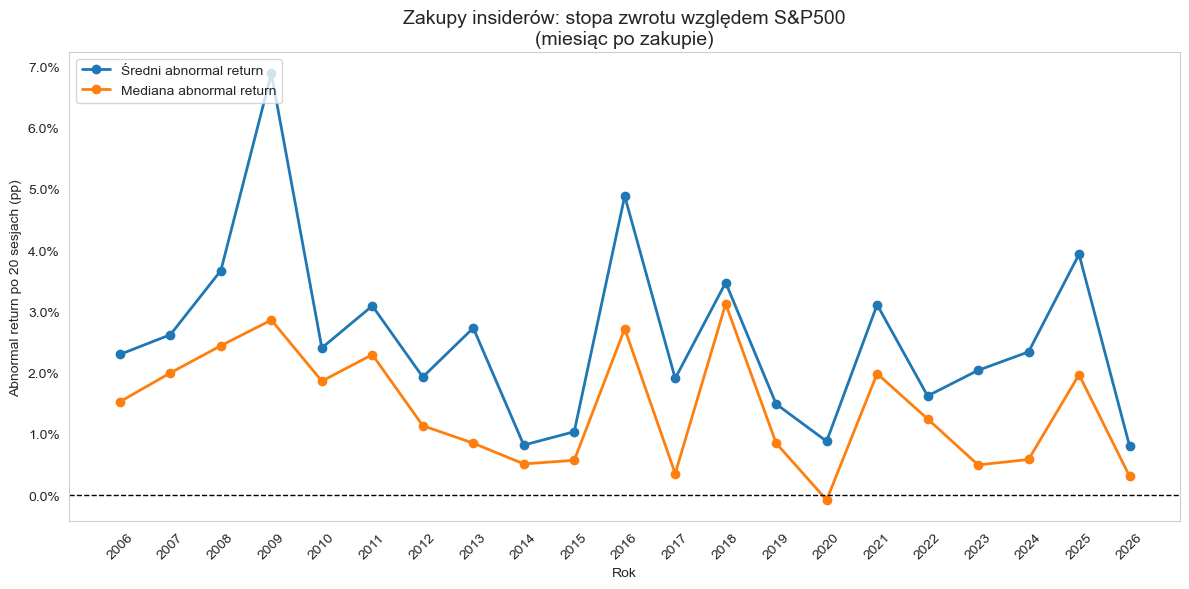

In [127]:
fig, ax = plt.subplots(figsize=(12,6))


ax.plot(
    abnormal_20d_yearly["year"],
    abnormal_20d_yearly["mean_abnormal_return"],
    color="#1f77b4",
    marker="o",
    linewidth=2,
    label="Średni abnormal return"
)


ax.plot(
    abnormal_20d_yearly["year"],
    abnormal_20d_yearly["median_abnormal_return"],
    color="#ff7f0e",
    marker="o",
    linewidth=2,
    label="Mediana abnormal return"
)


ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


ax.set_xlabel(
    "Rok"
)

ax.set_ylabel(
    "Abnormal return po 20 sesjach (pp)"
)


ax.set_title(
    "Zakupy insiderów: stopa zwrotu względem S&P500\n"
    "(miesiąc po zakupie)",
    fontsize=14
)


ax.set_xticks(
    abnormal_20d_yearly["year"]
)

ax.tick_params(
    axis="x",
    rotation=45
)


for x, n in zip(
    abnormal_20d_yearly["year"],
    abnormal_20d_yearly["n_obs"]
):
    ax.text(
        x,
        ax.get_ylim()[0],
        f"n={n}",
        ha="center",
        va="top",
        fontsize=0,
        color="white",
        rotation=90
    )


ax.legend(
    loc="upper left"
)


ax.grid(False)

plt.tight_layout()
plt.show()

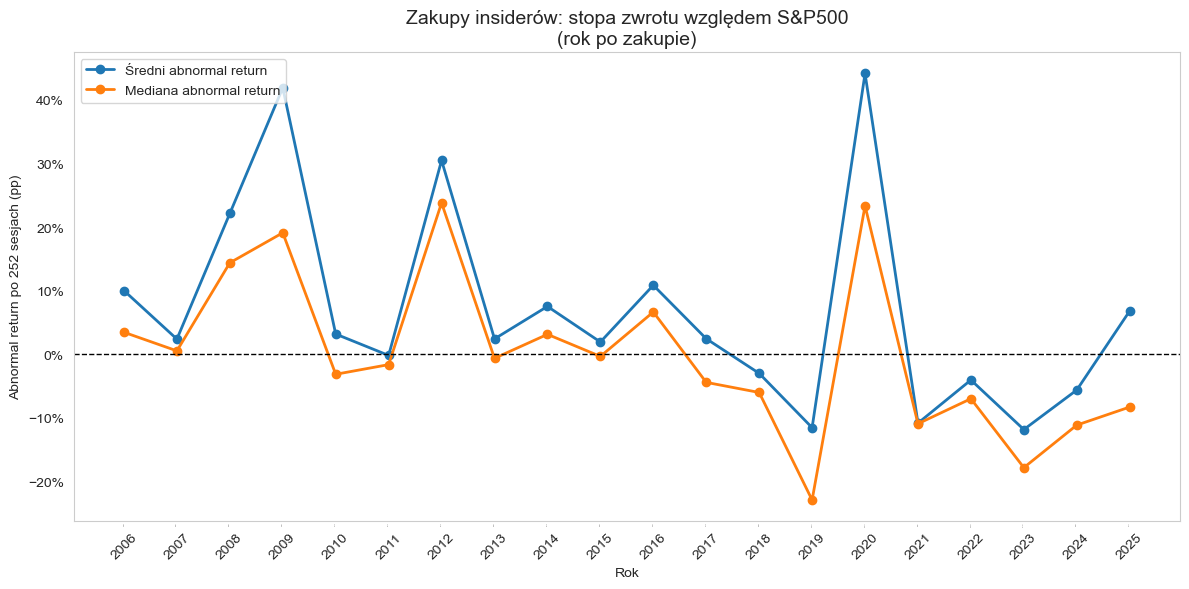

In [129]:
fig, ax = plt.subplots(figsize=(12,6))


ax.plot(
    abnormal_1y_yearly["year"],
    abnormal_1y_yearly["mean_abnormal_return"],
    color="#1f77b4",
    marker="o",
    linewidth=2,
    label="Średni abnormal return"
)


ax.plot(
    abnormal_1y_yearly["year"],
    abnormal_1y_yearly["median_abnormal_return"],
    color="#ff7f0e",
    marker="o",
    linewidth=2,
    label="Mediana abnormal return"
)


ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


ax.set_xlabel(
    "Rok"
)

ax.set_ylabel(
    "Abnormal return po 252 sesjach (pp)"
)


ax.set_title(
    "Zakupy insiderów: stopa zwrotu względem S&P500\n"
    "(rok po zakupie)",
    fontsize=14
)


ax.set_xticks(
    abnormal_1y_yearly["year"]
)

ax.tick_params(
    axis="x",
    rotation=45
)


for x, n in zip(
    abnormal_1y_yearly["year"],
    abnormal_1y_yearly["n_obs"]
):
    ax.text(
        x,
        ax.get_ylim()[0],
        f"n={n}",
        ha="center",
        va="top",
        fontsize=0,
        color="gray",
        rotation=90
    )


ax.legend(
    loc="upper left"
)


ax.grid(False)

plt.tight_layout()
plt.show()

In [131]:
rsp = yf.download(
    "RSP",
    start="2005-01-01",
    end="2026-12-31",
    auto_adjust=False
)


rsp

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,RSP,RSP,RSP,RSP,RSP,RSP
Date,,,,,,
2005-01-03,27.429573,38.500000,39.200001,38.485001,39.200001,247200
2005-01-04,27.046635,37.962502,38.650002,37.842499,38.650002,376000
2005-01-05,26.838234,37.669998,38.040001,37.669998,37.924999,206400
2005-01-06,26.918392,37.782501,37.910000,37.634998,37.787498,274800
2005-01-07,26.847155,37.682499,37.892502,37.555000,37.892502,277200
...,...,...,...,...,...,...
2026-07-27,215.179993,215.179993,215.839996,214.460007,214.800003,6002000
2026-07-28,217.690002,217.690002,218.050003,215.990005,216.169998,12864200


In [133]:
if isinstance(rsp.columns, pd.MultiIndex):
    rsp.columns = rsp.columns.get_level_values(0)


rsp = rsp.reset_index()

In [135]:
rsp

Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2005-01-03,27.429573,38.500000,39.200001,38.485001,39.200001,247200
1,2005-01-04,27.046635,37.962502,38.650002,37.842499,38.650002,376000
2,2005-01-05,26.838234,37.669998,38.040001,37.669998,37.924999,206400
3,2005-01-06,26.918392,37.782501,37.910000,37.634998,37.787498,274800
4,2005-01-07,26.847155,37.682499,37.892502,37.555000,37.892502,277200
...,...,...,...,...,...,...,...
5423,2026-07-27,215.179993,215.179993,215.839996,214.460007,214.800003,6002000
5424,2026-07-28,217.690002,217.690002,218.050003,215.990005,216.169998,12864200
5425,2026-07-29,215.729996,215.729996,218.110001,215.550003,217.199997,12991700
5426,2026-07-30,215.380005,215.380005,215.949997,213.059998,215.830002,13366300


In [137]:
rsp["Date"] = pd.to_datetime(
    rsp["Date"]
)

rsp = rsp.sort_values(
    "Date"
).reset_index(drop=True)

In [139]:
rsp["rsp_return_20d"] = (
    (
        rsp["Close"].shift(-20)
        /
        rsp["Close"]
        - 1
    )
    * 100
)

In [141]:
rsp["rsp_return_1y"] = (
    (
        rsp["Close"].shift(-252)
        /
        rsp["Close"]
        - 1
    )
    * 100
)

In [143]:
rsp[
    [
        "Date",
        "Close",
        "rsp_return_20d",
        "rsp_return_1y"
    ]
].tail(21)

Price,Date,Close,rsp_return_20d,rsp_return_1y
5407,2026-07-02,214.910004,0.046527,NaN
5408,2026-07-06,215.000000,NaN,NaN
5409,2026-07-07,214.729996,NaN,NaN
5410,2026-07-08,212.199997,NaN,NaN
5411,2026-07-09,213.500000,NaN,NaN
5412,2026-07-10,214.300003,NaN,NaN
5413,2026-07-13,214.229996,NaN,NaN
5414,2026-07-14,213.449997,NaN,NaN
5415,2026-07-15,212.970001,NaN,NaN
5416,2026-07-16,215.059998,NaN,NaN


In [145]:
df["date"] = pd.to_datetime(df["date"])
rsp["Date"] = pd.to_datetime(rsp["Date"])

In [147]:
df_rsp = df.merge(
    rsp[
        [
            "Date",
            "rsp_return_20d",
            "rsp_return_1y"
        ]
    ],
    left_on="date",
    right_on="Date",
    how="left"
)

In [149]:
df_rsp[
    "rsp_return_20d"
].isna().sum()

0

In [151]:
df_rsp["abnormal_return_rsp_20d"] = (
    df_rsp["return_20d_w"]
    -
    df_rsp["rsp_return_20d"]
)

In [153]:
df_rsp["abnormal_return_rsp_1y"] = (
    df_rsp["return_1y_w"]
    -
    df_rsp["rsp_return_1y"]
)

In [155]:
df_rsp

,date,action,company,ticker,name,title,shares,avg_price,value_usd,entry_price,...,price_1y_after,return_20d_w,return_1y_w,year,month,Date,rsp_return_20d,rsp_return_1y,abnormal_return_rsp_20d,abnormal_return_rsp_1y
0,2006-01-04,Purchased,COLUMBIA BANKING SYSTEM INC,COLB,WHITNEY EVANS Q,Executive Vice President,18192.00,10.820000,1.968374e+05,14.488955,...,17.373795,10.092643,19.910615,2006,2006-01,2006-01-04,1.248893,10.916052,8.843750,8.994563
1,2006-01-09,Purchased,CALAMOS STRATEGIC TOTAL RETURN FUND,CSQ,CALAMOS JOHN P SR,president and chairman,45800.00,13.972380,6.399350e+05,2.466409,...,2.974078,-0.071369,20.583302,2006,2006-01,2006-01-09,-1.460101,9.786198,1.388733,10.797103
2,2006-01-13,Purchased,FOSSIL INC,FOSL,KARTSOTIS KOSTA N,Pres. & CEO,70000.00,22.027543,1.541928e+06,22.139999,...,23.020000,-18.699185,3.974711,2006,2006-01,2006-01-13,-0.999304,11.410644,-17.699881,-7.435932
3,2006-01-13,Purchased,NVR INC,NVR,SCHAR DWIGHT C,Chairman,127.87,814.960000,1.042089e+05,785.250000,...,625.500000,-7.545368,-20.343840,2006,2006-01,2006-01-13,-0.999304,11.410644,-6.546064,-31.754483
4,2006-01-17,Purchased,STIFEL FINANCIAL CORP,SF,HIMELFARB RICHARD J,Director,80000.00,25.000000,2.000000e+06,6.662884,...,7.984721,-1.846078,19.838819,2006,2006-01,2006-01-17,0.397015,11.279780,-2.243094,8.559038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17144,2026-03-30,Purchased,"CITIZENS, INC.",CIA,Stenberg Jon,President & CEO,50000.00,4.700000,2.350000e+05,4.820000,...,NaN,18.879664,NaN,2026,2026-03,2026-03-30,6.747481,NaN,12.132184,NaN
17145,2026-03-30,Purchased,Sibanye Stillwater Ltd,SBSW,Carter Charles Edward,Chief Regional Officer: Amer.,10000.00,11.400000,1.140000e+05,11.140000,...,NaN,7.091561,NaN,2026,2026-03,2026-03-30,6.747481,NaN,0.344081,NaN
17146,2026-03-30,Purchased,TAIWAN SEMICONDUCTOR MANUFACTURING CO LTD,TSM,Lin Shyue-Shyh,VP,3000.00,54.720000,1.641600e+05,315.760529,...,NaN,23.962087,NaN,2026,2026-03,2026-03-30,6.747481,NaN,17.214606,NaN
17147,2026-03-30,Purchased,"Zenas BioPharma, Inc.",ZBIO,MOULDER LEON O JR,Chief Executive Officer,20000.00,18.230000,3.646000e+05,18.225000,...,NaN,-1.179699,NaN,2026,2026-03,2026-03-30,6.747481,NaN,-7.927180,NaN


In [157]:
df_rsp_1y_clean = df_rsp.dropna(
    subset=[
        "return_1y_w",
        "rsp_return_1y",
        "abnormal_return_rsp_1y"
    ]
)

In [159]:
df_rsp_1y_clean

,date,action,company,ticker,name,title,shares,avg_price,value_usd,entry_price,...,price_1y_after,return_20d_w,return_1y_w,year,month,Date,rsp_return_20d,rsp_return_1y,abnormal_return_rsp_20d,abnormal_return_rsp_1y
0,2006-01-04,Purchased,COLUMBIA BANKING SYSTEM INC,COLB,WHITNEY EVANS Q,Executive Vice President,18192.00,10.820000,1.968374e+05,14.488955,...,17.373795,10.092643,19.910615,2006,2006-01,2006-01-04,1.248893,10.916052,8.843750,8.994563
1,2006-01-09,Purchased,CALAMOS STRATEGIC TOTAL RETURN FUND,CSQ,CALAMOS JOHN P SR,president and chairman,45800.00,13.972380,6.399350e+05,2.466409,...,2.974078,-0.071369,20.583302,2006,2006-01,2006-01-09,-1.460101,9.786198,1.388733,10.797103
2,2006-01-13,Purchased,FOSSIL INC,FOSL,KARTSOTIS KOSTA N,Pres. & CEO,70000.00,22.027543,1.541928e+06,22.139999,...,23.020000,-18.699185,3.974711,2006,2006-01,2006-01-13,-0.999304,11.410644,-17.699881,-7.435932
3,2006-01-13,Purchased,NVR INC,NVR,SCHAR DWIGHT C,Chairman,127.87,814.960000,1.042089e+05,785.250000,...,625.500000,-7.545368,-20.343840,2006,2006-01,2006-01-13,-0.999304,11.410644,-6.546064,-31.754483
4,2006-01-17,Purchased,STIFEL FINANCIAL CORP,SF,HIMELFARB RICHARD J,Director,80000.00,25.000000,2.000000e+06,6.662884,...,7.984721,-1.846078,19.838819,2006,2006-01,2006-01-17,0.397015,11.279780,-2.243094,8.559038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15848,2025-04-28,Purchased,"Saker Aviation Services, Inc.",SKAS,WACHTEL WILLIAM B,President and CEO,108817.00,8.630000,9.390907e+05,7.500000,...,6.750000,3.693333,-10.000000,2025,2025-04,2025-04-28,5.752742,19.348503,-2.059409,-29.348503
15849,2025-04-28,Purchased,"Third Coast Bancshares, Inc.",TCBX,MCWHORTER RICHARD J,Chief Financial Officer,10000.00,29.208910,2.920891e+05,28.780001,...,37.259998,10.945099,29.464897,2025,2025-04,2025-04-28,5.752742,19.348503,5.192358,10.116394
15850,2025-04-29,Purchased,Matador Resources Co,MTDR,Foran Joseph Wm,Chairman and CEO,5000.00,40.860000,2.043000e+05,39.495605,...,63.011890,7.639892,59.541523,2025,2025-04,2025-04-29,4.245124,20.449976,3.394769,39.091547
15851,2025-04-29,Purchased,Merchants Bancorp,MBIN,Dunlap Michael J.,"President, COO",4000.00,30.594260,1.223770e+05,30.281502,...,46.437836,6.026041,53.353807,2025,2025-04,2025-04-29,4.245124,20.449976,1.780917,32.903831


In [161]:
rsp_20d_stats = {
    "mean": df_rsp["abnormal_return_rsp_20d"].mean(),
    "median": df_rsp["abnormal_return_rsp_20d"].median(),
    "hit_rate": (
        df_rsp["abnormal_return_rsp_20d"] > 0
    ).mean(),
    "N": df_rsp["abnormal_return_rsp_20d"].count()
}


rsp_20d_stats

{'mean': 2.6874537401759926,
 'median': 1.5032402019332647,
 'hit_rate': 0.5756020759227943,
 'N': 17149}

In [163]:
rsp_1y_stats = {
    "mean": df_rsp_1y_clean["abnormal_return_rsp_1y"].mean(),
    "median": df_rsp_1y_clean["abnormal_return_rsp_1y"].median(),
    "hit_rate": (
        df_rsp_1y_clean["abnormal_return_rsp_1y"] > 0
    ).mean(),
    "N": df_rsp_1y_clean["abnormal_return_rsp_1y"].count()
}


rsp_1y_stats

{'mean': 6.402707134440217,
 'median': -0.8405469361827844,
 'hit_rate': 0.48890714872637636,
 'N': 15821}

In [165]:
comparison = pd.DataFrame({
    "Metryka": [
        "Średnia stopa zwrotu",
        "Mediana",
        "Hit rate"
    ],
    
    "vs S&P500": [
        df_market["abnormal_return_20d"].mean(),
        df_market["abnormal_return_20d"].median(),
        (df_market["abnormal_return_20d"] > 0).mean()
    ],
    
    "vs RSP equal weight": [
        df_rsp["abnormal_return_rsp_20d"].mean(),
        df_rsp["abnormal_return_rsp_20d"].median(),
        (df_rsp["abnormal_return_rsp_20d"] > 0).mean()
    ]
})

comparison

,Metryka,vs S&P500,vs RSP equal weight
0,Średnia stopa zwrotu,2.477214,2.687454
1,Mediana,1.388222,1.503240
2,Hit rate,0.562832,0.575602


In [167]:
df_rsp_1y_clean = df_rsp.dropna(
    subset=[
        "return_1y_w",
        "rsp_return_1y",
        "abnormal_return_rsp_1y"
    ]
)

In [169]:
rsp_1y_summary = pd.DataFrame({
    "Metryka": [
        "Średnia stopa zwrotu akcji insiderów",
        "Średnia stopa zwrotu RSP",
        "Średni abnormal return",
        "Mediana abnormal return",
        "Hit rate abnormal return",
        "Liczba obserwacji"
    ],
    
    "Wartość": [
        df_rsp_1y_clean["return_1y_w"].mean(),
        df_rsp_1y_clean["rsp_return_1y"].mean(),
        df_rsp_1y_clean["abnormal_return_rsp_1y"].mean(),
        df_rsp_1y_clean["abnormal_return_rsp_1y"].median(),
        (
            df_rsp_1y_clean["abnormal_return_rsp_1y"] > 0
        ).mean(),
        df_rsp_1y_clean["abnormal_return_rsp_1y"].count()
    ]
})


rsp_1y_summary

,Metryka,Wartość
0,Średnia stopa zwrotu akcji insiderów,17.047891
1,Średnia stopa zwrotu RSP,10.645184
2,Średni abnormal return,6.402707
3,Mediana abnormal return,-0.840547
4,Hit rate abnormal return,0.488907
5,Liczba obserwacji,15821.000000


In [171]:
abnormal_rsp_1y_yearly = df_rsp_1y_clean.groupby("year").agg(
    mean_abnormal_return=(
        "abnormal_return_rsp_1y",
        "mean"
    ),
    median_abnormal_return=(
        "abnormal_return_rsp_1y",
        "median"
    ),
    hit_rate=(
        "abnormal_return_rsp_1y",
        lambda x: (x > 0).mean()
    ),
    n_obs=(
        "abnormal_return_rsp_1y",
        "count"
    )
).reset_index()


abnormal_rsp_1y_yearly = abnormal_rsp_1y_yearly[
    (abnormal_rsp_1y_yearly["year"] >= 2006) &
    (abnormal_rsp_1y_yearly["year"] <= 2025)
]

In [173]:
abnormal_rsp_1y_yearly

,year,mean_abnormal_return,median_abnormal_return,hit_rate,n_obs
0,2006,10.414522,3.875840,0.604706,425
1,2007,5.159046,3.460497,0.548552,587
2,2008,15.901473,10.856063,0.600237,843
3,2009,25.549670,3.920237,0.533854,384
4,2010,0.047462,-7.247311,0.389121,478
5,2011,2.347340,0.295529,0.502976,672
6,2012,24.982185,19.333224,0.678261,575
7,2013,0.576179,-2.056420,0.429603,554
8,2014,8.463458,4.110046,0.562963,675
9,2015,1.661441,-0.698629,0.479879,994


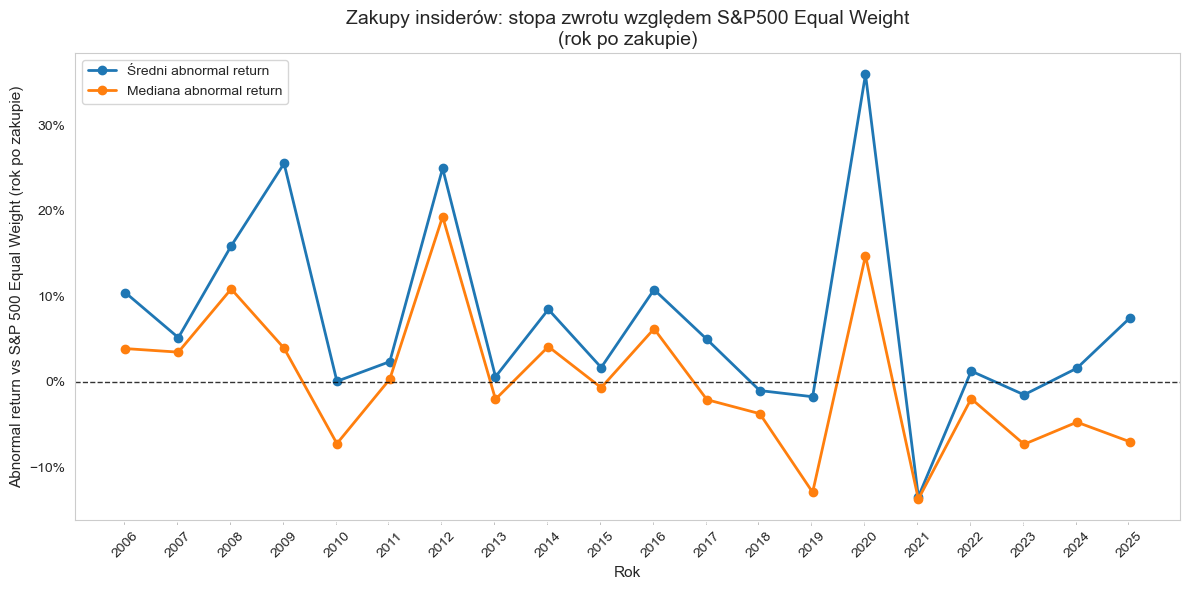

In [175]:
fig, ax = plt.subplots(figsize=(12,6))


ax.plot(
    abnormal_rsp_1y_yearly["year"],
    abnormal_rsp_1y_yearly["mean_abnormal_return"],
    color="#1f77b4",
    marker="o",
    linewidth=2,
    label="Średni abnormal return"
)


ax.plot(
    abnormal_rsp_1y_yearly["year"],
    abnormal_rsp_1y_yearly["median_abnormal_return"],
    color="#ff7f0e",
    marker="o",
    linewidth=2,
    label="Mediana abnormal return"
)


ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.8
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


ax.set_ylabel(
    "Abnormal return vs S&P 500 Equal Weight (rok po zakupie)",
    fontsize=11
)


ax.set_xlabel(
    "Rok",
    fontsize=11
)


ax.set_title(
    "Zakupy insiderów: stopa zwrotu względem S&P500 Equal Weight\n"
    "(rok po zakupie)",
    fontsize=14
)


ax.set_xticks(
    abnormal_rsp_1y_yearly["year"]
)


ax.tick_params(
    axis="x",
    rotation=45
)


for x, n in zip(
    abnormal_rsp_1y_yearly["year"],
    abnormal_rsp_1y_yearly["n_obs"]
):
    ax.text(
        x,
        ax.get_ylim()[0],
        f"n={n}",
        ha="center",
        va="top",
        fontsize=0,
        color="gray",
        rotation=90
    )


ax.legend(
    loc="upper left"
)


ax.grid(False)


plt.tight_layout()
plt.show()

In [177]:
abnormal_rsp_20d_yearly = df_rsp.groupby("year").agg(
    mean_abnormal_return=(
        "abnormal_return_rsp_20d",
        "mean"
    ),
    median_abnormal_return=(
        "abnormal_return_rsp_20d",
        "median"
    ),
    hit_rate=(
        "abnormal_return_rsp_20d",
        lambda x: (x.dropna() > 0).mean()
    ),
    n_obs=(
        "abnormal_return_rsp_20d",
        "count"
    )
).reset_index()


abnormal_rsp_20d_yearly = abnormal_rsp_20d_yearly[
    (abnormal_rsp_20d_yearly["year"] >= 2006) &
    (abnormal_rsp_20d_yearly["year"] <= 2026)
]

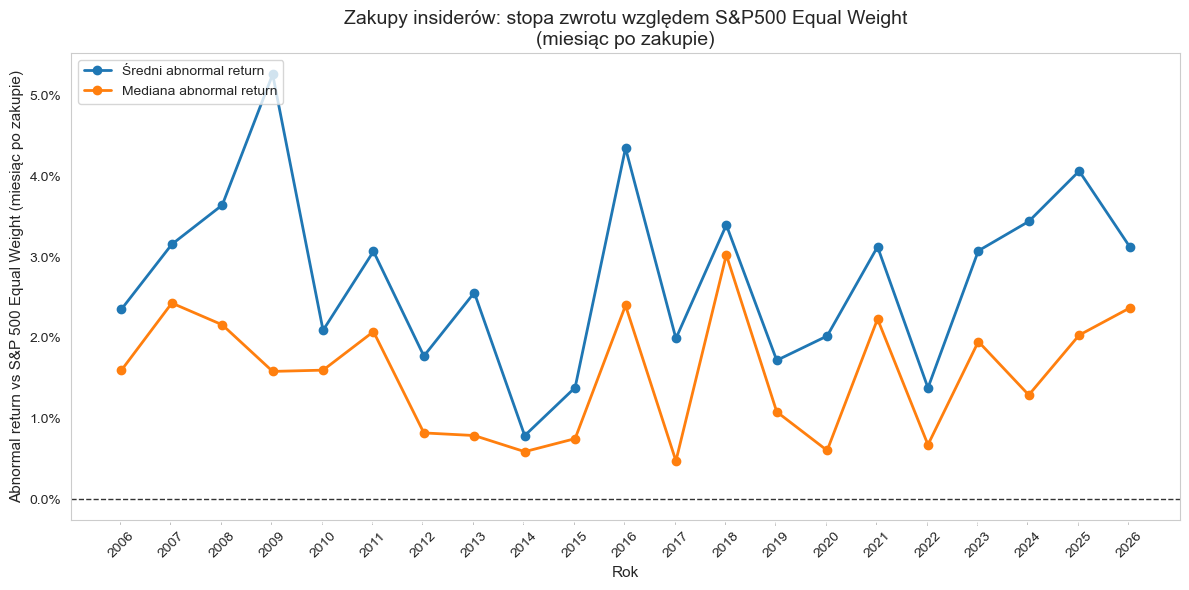

In [179]:
fig, ax = plt.subplots(figsize=(12,6))


ax.plot(
    abnormal_rsp_20d_yearly["year"],
    abnormal_rsp_20d_yearly["mean_abnormal_return"],
    color="#1f77b4",
    marker="o",
    linewidth=2,
    label="Średni abnormal return"
)


ax.plot(
    abnormal_rsp_20d_yearly["year"],
    abnormal_rsp_20d_yearly["median_abnormal_return"],
    color="#ff7f0e",
    marker="o",
    linewidth=2,
    label="Mediana abnormal return"
)


ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.8
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


ax.set_ylabel(
    "Abnormal return vs S&P 500 Equal Weight (miesiąc po zakupie)",
    fontsize=11
)


ax.set_xlabel(
    "Rok",
    fontsize=11
)


ax.set_title(
    "Zakupy insiderów: stopa zwrotu względem S&P500 Equal Weight\n"
    "(miesiąc po zakupie)",
    fontsize=14
)


ax.set_xticks(
    abnormal_rsp_20d_yearly["year"]
)


ax.tick_params(
    axis="x",
    rotation=45
)


for x, n in zip(
    abnormal_rsp_20d_yearly["year"],
    abnormal_rsp_20d_yearly["n_obs"]
):
    ax.text(
        x,
        ax.get_ylim()[0],
        f"n={n}",
        ha="center",
        va="top",
        fontsize=0,
        color="gray",
        rotation=90
    )


ax.legend(
    loc="upper left"
)


ax.grid(False)


plt.tight_layout()
plt.show()

In [181]:
summary_20d = pd.DataFrame({
    "Benchmark": [
        "Brak benchmarku",
        "S&P500 cap-weighted",
        "S&P500 equal-weighted (RSP)"
    ],

    "Średnia stopa zwrotu / AR": [
        df["return_20d_w"].mean(),
        df_market["abnormal_return_20d"].mean(),
        df_rsp["abnormal_return_rsp_20d"].mean()
    ],

    "Mediana": [
        df["return_20d_w"].median(),
        df_market["abnormal_return_20d"].median(),
        df_rsp["abnormal_return_rsp_20d"].median()
    ],

    "Hit rate": [
        (df["return_20d_w"] > 0).mean(),
        (df_market["abnormal_return_20d"] > 0).mean(),
        (df_rsp["abnormal_return_rsp_20d"] > 0).mean()
    ],

    "N": [
        df["return_20d_w"].count(),
        df_market["abnormal_return_20d"].count(),
        df_rsp["abnormal_return_rsp_20d"].count()
    ]
})


summary_20d

,Benchmark,Średnia stopa zwrotu / AR,Mediana,Hit rate,N
0,Brak benchmarku,3.311416,2.306210,0.612281,17149
1,S&P500 cap-weighted,2.477214,1.388222,0.562832,17018
2,S&P500 equal-weighted (RSP),2.687454,1.503240,0.575602,17149


In [191]:
df_market_1y_clean = df_market_1y.dropna(
    subset=[
        "return_1y_w",
        "sp500_return_1y",
        "abnormal_return_1y"
    ]
)

In [193]:
summary_1y = pd.DataFrame({
    "Benchmark": [
        "Brak benchmarku",
        "S&P500 cap-weighted",
        "S&P500 equal-weighted (RSP)"
    ],

    "Średnia stopa zwrotu / AR": [
        df_rsp_1y_clean["return_1y_w"].mean(),
        df_market_1y_clean["abnormal_return_1y"].mean(),
        df_rsp_1y_clean["abnormal_return_rsp_1y"].mean()
    ],

    "Mediana": [
        df_rsp_1y_clean["return_1y_w"].median(),
        df_market_1y_clean["abnormal_return_1y"].median(),
        df_rsp_1y_clean["abnormal_return_rsp_1y"].median()
    ],

    "Hit rate": [
        (df_rsp_1y_clean["return_1y_w"] > 0).mean(),
        (df_market_1y_clean["abnormal_return_1y"] > 0).mean(),
        (df_rsp_1y_clean["abnormal_return_rsp_1y"] > 0).mean()
    ],

    "N": [
        len(df_rsp_1y_clean),
        len(df_market_1y_clean),
        len(df_rsp_1y_clean)
    ]
})


summary_1y

,Benchmark,Średnia stopa zwrotu / AR,Mediana,Hit rate,N
0,Brak benchmarku,17.047891,7.705830,0.585108,15821
1,S&P500 cap-weighted,5.488206,-1.871496,0.475864,15744
2,S&P500 equal-weighted (RSP),6.402707,-0.840547,0.488907,15821


In [197]:
df = df.sort_values(
    [
        "ticker",
        "date"
    ]
).copy()

In [199]:
cluster_flag = []

for ticker, group in df.groupby("ticker"):

    group = group.sort_values("date")

    dates = group["date"].tolist()
    names = group["name"].tolist()

    flags = []

    for i in range(len(group)):

        current_date = dates[i]
        current_name = names[i]

        window = group[
            (group["date"] >= current_date - pd.Timedelta(days=5)) &
            (group["date"] <= current_date + pd.Timedelta(days=5))
        ]

        other_insiders = (
            window[
                window["name"] != current_name
            ]["name"]
            .nunique()
        )

        flags.append(
            other_insiders >= 1
        )

    cluster_flag.extend(flags)

In [200]:
print(cluster_flag)

[False, False, False, False, False, False, False, False, False, False, False, False, True, True, True, True, True, True, False, False, False, False, False, False, False, False, False, False, False, True, True, False, False, False, False, False, False, False, True, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, F

In [203]:
df["cluster_buy"] = np.where(
    cluster_flag,
    "Yes",
    "No"
)

In [205]:
df["cluster_buy"].value_counts()

cluster_buy
No     12017
Yes     5132
Name: count, dtype: int64

In [207]:
cluster_stats = df.groupby(
    "cluster_buy"
).agg(
    n_obs=("return_20d_w","count"),
    mean_return=("return_20d_w","mean"),
    median_return=("return_20d_w","median"),
    hit_rate=(
        "return_20d_w",
        lambda x: (x > 0).mean()
    )
)

cluster_stats

,n_obs,mean_return,median_return,hit_rate
cluster_buy,,,,
No,12017,3.351486,2.337066,0.613714
Yes,5132,3.217589,2.206393,0.608924


In [209]:
cluster_year = df.groupby(
    [
        "year",
        "cluster_buy"
    ]
).agg(
    mean_return=("return_20d_w","mean"),
    median_return=("return_20d_w","median"),
    hit_rate=(
        "return_20d_w",
        lambda x: (x > 0).mean()
    ),
    n_obs=("return_20d_w","count")
).reset_index()

In [211]:
cluster_year

,year,cluster_buy,mean_return,median_return,hit_rate,n_obs
0,2006,No,2.959128,1.927004,0.616715,347
1,2006,Yes,3.971350,2.850051,0.769231,78
2,2007,No,2.747871,2.842889,0.642857,448
3,2007,Yes,3.388228,3.886897,0.683453,139
4,2008,No,1.813251,0.962945,0.532727,550
5,2008,Yes,0.543138,-0.455928,0.467577,293
6,2009,No,10.297019,6.097580,0.719243,317
7,2009,Yes,14.340793,6.206884,0.776119,67
8,2010,No,4.148261,3.268805,0.671679,399
9,2010,Yes,1.741943,0.476217,0.506329,79


In [213]:
cluster_stats_1y = df.groupby(
    "cluster_buy"
).agg(
    n_obs=("return_1y_w", "count"),
    mean_return=("return_1y_w", "mean"),
    median_return=("return_1y_w", "median"),
    hit_rate=(
        "return_1y_w",
        lambda x: (x.dropna() > 0).mean()
    )
)

cluster_stats_1y

,n_obs,mean_return,median_return,hit_rate
cluster_buy,,,,
No,11133,16.304899,7.199381,0.581065
Yes,4688,18.812339,9.355194,0.594710


In [215]:
df["date"] = pd.to_datetime(df["date"])

cluster_events = []

for ticker, company_df in df.groupby("ticker"):

    company_df = company_df.sort_values("date").copy()

    # Jeden rekord na dzień (potrzebny tylko do iteracji po dniach)
    trading_days = (
        company_df["date"]
        .drop_duplicates()
        .sort_values()
    )

    cluster_active = False

    for current_date in trading_days:

        # okno 5 dni wstecz
        window = company_df[
            (company_df["date"] >= current_date - pd.Timedelta(days=5)) &
            (company_df["date"] <= current_date)
        ]

        n_unique_insiders = window["name"].nunique()

        if n_unique_insiders >= 2:

            # tylko pierwszy dzień klastra
            if not cluster_active:

                cluster_active = True

                signal_day = company_df[
                    company_df["date"] == current_date
                ]

                # pierwszy rekord z dnia - potrzebny do pobrania stóp zwrotu
                signal = signal_day.iloc[0]

                cluster_events.append({

                    "ticker": ticker,
                    "company": signal["company"],
                    "signal_date": current_date,

                    # siła klastra
                    "cluster_size": n_unique_insiders,
                    "transactions_in_window": len(window),
                    "insiders_on_signal_day": signal_day["name"].nunique(),

                    # wartość zakupów w dniu sygnału
                    "value_usd_signal_day": signal_day["value_usd"].sum(),

                    # stopy zwrotu
                    "return_20d_w": signal["return_20d_w"],
                    "return_1y_w": signal["return_1y_w"],

                    # ceny
                    "entry_price": signal["entry_price"],
                    "price_20d_after": signal["price_20d_after"],
                    "price_1y_after": signal["price_1y_after"]
                })

        else:
            # klaster się zakończył
            cluster_active = False


cluster_events = pd.DataFrame(cluster_events)

In [216]:
len(cluster_events)

1414

In [219]:
cluster_stats_20d = cluster_events.agg(
    n_obs=("return_20d_w", "count"),
    mean_return=("return_20d_w", "mean"),
    median_return=("return_20d_w", "median"),
    std_return=("return_20d_w", "std"),
    hit_rate=("return_20d_w", lambda x: (x > 0).mean())
)

cluster_stats_20d = pd.DataFrame(cluster_stats_20d).T

cluster_stats_20d["hit_rate"] *= 100

cluster_stats_20d.round(2)

,n_obs,mean_return,median_return,std_return,hit_rate
return_20d_w,1414.0,3.62,2.42,15.36,61.24


In [221]:
cluster_stats_1y = cluster_events.agg(
    n_obs=("return_1y_w", "count"),
    mean_return=("return_1y_w", "mean"),
    median_return=("return_1y_w", "median"),
    std_return=("return_1y_w", "std"),
    hit_rate=("return_1y_w", lambda x: (x.dropna() > 0).mean())
)

cluster_stats_1y = pd.DataFrame(cluster_stats_1y).T

cluster_stats_1y["hit_rate"] *= 100

cluster_stats_1y.round(2)

,n_obs,mean_return,median_return,std_return,hit_rate
return_1y_w,1313.0,18.49,7.45,64.12,56.66


In [223]:
comparison_20d = pd.DataFrame({
    "Strategia": [
        "Wszystkie zakupy",
        "Cluster buy"
    ],
    "N": [
        df["return_20d_w"].count(),
        cluster_events["return_20d_w"].count()
    ],
    "Średnia (%)": [
        df["return_20d_w"].mean(),
        cluster_events["return_20d_w"].mean()
    ],
    "Mediana (%)": [
        df["return_20d_w"].median(),
        cluster_events["return_20d_w"].median()
    ],
    "Odch. std.": [
        df["return_20d_w"].std(),
        cluster_events["return_20d_w"].std()
    ],
    "Hit rate (%)": [
        (df["return_20d_w"] > 0).mean() * 100,
        (cluster_events["return_20d_w"] > 0).mean() * 100
    ]
}).round(2)

comparison_20d

,Strategia,N,Średnia (%),Mediana (%),Odch. std.,Hit rate (%)
0,Wszystkie zakupy,17149,3.31,2.31,14.69,61.23
1,Cluster buy,1414,3.62,2.42,15.36,61.24


In [225]:
comparison_1y = pd.DataFrame({
    "Strategia": [
        "Wszystkie zakupy",
        "Cluster buy"
    ],
    "N": [
        df["return_1y_w"].count(),
        cluster_events["return_1y_w"].count()
    ],
    "Średnia (%)": [
        df["return_1y_w"].mean(),
        cluster_events["return_1y_w"].mean()
    ],
    "Mediana (%)": [
        df["return_1y_w"].median(),
        cluster_events["return_1y_w"].median()
    ],
    "Odch. std.": [
        df["return_1y_w"].std(),
        cluster_events["return_1y_w"].std()
    ],
    "Hit rate (%)": [
        (df["return_1y_w"].dropna() > 0).mean() * 100,
        (cluster_events["return_1y_w"].dropna() > 0).mean() * 100
    ]
}).round(2)

comparison_1y

,Strategia,N,Średnia (%),Mediana (%),Odch. std.,Hit rate (%)
0,Wszystkie zakupy,15821,17.05,7.71,61.40,58.51
1,Cluster buy,1313,18.49,7.45,64.12,56.66
